# SIMM59 Lab 2: Applications of NLP
## Sentiment Analysis and Vector Representations of Sustainability Communication

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/simm59/simm59_lab2.ipynb)

### Overview

This lab introduces two complementary NLP methods applied to Equinor's sustainability communication:

**Part 1 — Sentiment Analysis** *(Ghosh & Gunning 2019, Ch. 8)*  
Dictionary-based sentiment scoring using the AFINN lexicon — a simple, transparent, non-inferential method that assigns a polarity score to each token and aggregates across documents. Builds directly on the cleaned token output (`df_tokens`) from Lab 1.

**Part 2 — Vector Representations** *(Ghosh & Gunning 2019, Ch. 7)*  
Representing words and documents as numeric vectors using spaCy's pre-trained `en_core_web_md` model. Enables cosine similarity comparisons between documents and between key terms, and 2D visualization of the semantic space.

### Prerequisites
- Google Drive mounted with corpus texts and Lab 1 output in place
- `spacy` with `en_core_web_md` model (pre-installed in Colab)
- `afinn` package (installed in Section 1 below)

## Setup: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Update Google Drive path below to match your files
corpus_dir = '/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor'

files = sorted(os.listdir(corpus_dir))
print(f"Files in {corpus_dir}:\n")
for f in files:
    fpath = os.path.join(corpus_dir, f)
    size = os.path.getsize(fpath)
    print(f"  {f}  ({size:,} bytes)")

Files in /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor:

  df_esg.tsv  (18,464 bytes)
  equinor01-protecting-the-environment.pdf  (1,733,200 bytes)
  equinor01-protecting-the-environment.txt  (3,057 bytes)
  equinor02-health-safety-and-security.pdf  (3,388,604 bytes)
  equinor02-health-safety-and-security.txt  (10,463 bytes)
  equinor03-human-rights.pdf  (6,803,451 bytes)
  equinor03-human-rights.txt  (6,240 bytes)
  equinor04-governance-and-transparency.pdf  (1,977,710 bytes)
  equinor04-governance-and-transparency.txt  (8,790 bytes)
  equinor05-our-transition-ambitions.pdf  (3,360,967 bytes)
  equinor05-our-transition-ambitions.txt  (7,887 bytes)
  equinor06-a-just-energy-transition.pdf  (8,479,542 bytes)
  equinor06-a-just-energy-transition.txt  (8,714 bytes)
  equinor07-environmental-social-and-governance-esg-reporting-centre.pdf  (1,686,059 bytes)
  equinor07-environmental-social-and-governance-esg-reporting-centre.txt  (2,749 bytes)
  equinor08-impact-assessments.pdf  

## AFINN Sentiment Analysis
*(Ghosh & Gunning 2019, Ch. 8)*

**Sentiment analysis** is the area of NLP that involves automatically identifying the tone or *polarity* of written text — whether it is positive, negative, or neutral (Ghosh & Gunning, p. 270). It is widely used for brand monitoring, customer feedback, and increasingly for analysing organizational communication.

### Why a dictionary-based approach first?

There are several sentiment analysis tools available (Ch. 8, pp. 274–276):

| Approach | Examples | When useful |
|---|---|---|
| **Dictionary/lexicon** | AFINN, VADER | Transparent, no training data needed, easy to audit |
| **Python NLP libraries** | TextBlob, spaCy | Simple API, moderate accuracy |
| **Deep learning** | BERT-based models | Highest accuracy, needs compute |

We begin with **AFINN** (Nielsen 2011) — a hand-curated list of ~3,500 English words each rated on a scale from −5 (most negative) to +5 (most positive). For each document, we look up every token in the AFINN lexicon and compute the mean score across all scored tokens. This gives a **polarity score**: positive values indicate net positive sentiment, negative values indicate net negative sentiment.

**Key concept — polarity** (Ch. 8, p. 273): *"Polarity is a measure of how negative or positive the sentiment is in a given language source ... Values close to 1 reflect documents that have positive sentiments, whereas values close to 0 reflect documents that have negative sentiments."*

### Input
We use `df_tokens.tsv` produced in Lab 1 — cleaned, lemmatized content tokens, one row per token per document. This means stop words, punctuation, and artefacts have already been removed, so AFINN scores reflect only content-bearing vocabulary.

In [ ]:
# ── Install afinn and load df_tokens from Lab 1 output ────────────────────────
import subprocess
subprocess.run(["pip", "install", "afinn", "-q"], check=True)

import random
from afinn import Afinn

# 1. Initialize Afinn (English is default)
afinn = Afinn()

# 2. Get the full word dictionary
# afinn._dict is a dictionary of {word: score}
all_words = list(afinn._dict.items())

# 3. Sample 20 random pairs
random_sample = random.sample(all_words, 20)

# 4. Print results
print(f"{'Word':<20} | {'Score':>5}")
print("-" * 28)
for word, score in random_sample:
    print(f"{word:<20} | {score:>5}")

Word                 | Score
----------------------------
costly               |    -2
tribute              |     2
lool                 |     3
dont like            |    -2
fulfilled            |     2
ghost                |    -1
ensuring             |     1
genial               |     3
vividly              |     2
rapturous            |     4
pardoning            |     2
brave                |     2
poor                 |    -2
affected             |    -1
looool               |     3
victimized           |    -3
depressed            |    -2
splendid             |     3
abandoned            |    -2
fatal                |    -3


Example files on [Google Drive](https://drive.google.com/drive/folders/1MyDJTsu-_Ou81zdq4Mt9taH6pad1Mj8j?usp=sharing).

In [ ]:
import pandas as pd
from afinn import Afinn

# Update Google Drive path below to match your files
tokens_path = '/content/drive/MyDrive/doc/sfac/simm59/2026/output/df_tokens.tsv'
df_tokens = pd.read_csv(tokens_path, sep='\t')

print(f"Loaded df_tokens: {len(df_tokens):,} tokens across {df_tokens['filename'].nunique()} documents")
print(f"Columns: {list(df_tokens.columns)}")
df_tokens.head()

Loaded df_tokens: 6,906 tokens across 9 documents
Columns: ['filename', 'sentence_id', 'token_id', 'token']


,filename,sentence_id,token_id,token
0,equinor01-protecting-the-environment.txt,1,1,protect
1,equinor01-protecting-the-environment.txt,1,2,environment
2,equinor01-protecting-the-environment.txt,1,3,home
3,equinor01-protecting-the-environment.txt,1,4,sustainability
4,equinor01-protecting-the-environment.txt,1,5,protect


In [ ]:
# ── AFINN sentiment scoring ────────────────────────────────────────────────────
afinn = Afinn()

# Score each token against the AFINN lexicon
# Tokens not found in the lexicon receive 0
df_tokens['afinn_score'] = df_tokens['token'].apply(afinn.score)

# Aggregate per document
df_sentiment = (
    df_tokens.groupby('filename')
    .agg(
        total_tokens   = ('token',       'count'),
        scored_tokens  = ('afinn_score', lambda x: (x != 0).sum()),
        score_sum      = ('afinn_score', 'sum'),
        score_mean     = ('afinn_score', 'mean'),
    )
    .reset_index()
)

# Readable short label for plotting
df_sentiment['label'] = (
    df_sentiment['filename']
    .str.replace(r'^equinor\d+-', '', regex=True)
    .str.replace('.txt', '', regex=False)
    .str.replace('-', ' ', regex=False)
)

print(df_sentiment[['label', 'total_tokens', 'scored_tokens', 'score_sum', 'score_mean']]
      .to_string(index=False))

                                                   label  total_tokens  scored_tokens  score_sum  score_mean
                              protecting the environment           258             26        2.0    0.007752
                              health safety and security           891            169       13.0    0.014590
                                            human rights           548             46        8.0    0.014599
                             governance and transparency           734            108       85.0    0.115804
                                our transition ambitions           682             43       54.0    0.079179
                                a just energy transition           721             87      109.0    0.151179
environmental social and governance esg reporting centre           240             18        8.0    0.033333
                                      impact assessments          2364             65      -27.0   -0.011421
                   

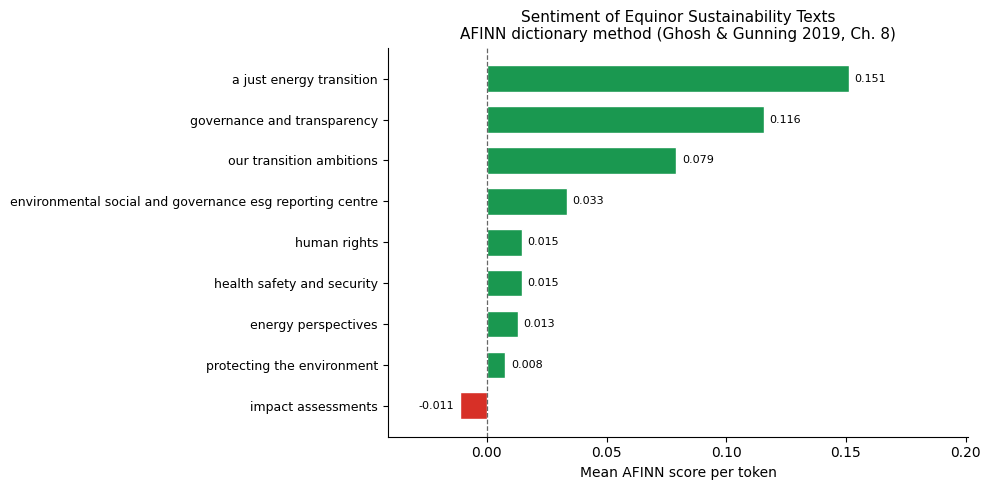

In [ ]:
# ── Horizontal bar chart: AFINN sentiment per document ────────────────────────
import matplotlib.pyplot as plt

df_plot = df_sentiment.sort_values('score_mean').reset_index(drop=True)

colors = ['#d73027' if v < 0 else '#1a9850' for v in df_plot['score_mean']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_plot['label'], df_plot['score_mean'],
               color=colors, edgecolor='white', height=0.65)

ax.axvline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.6)
ax.set_xlabel('Mean AFINN score per token', fontsize=10)
ax.set_title(
    'Sentiment of Equinor Sustainability Texts\n'
    'AFINN dictionary method (Ghosh & Gunning 2019, Ch. 8)',
    fontsize=11
)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=8)
ax.set_xlim(df_plot['score_mean'].min() - 0.03,
            df_plot['score_mean'].max() + 0.05)
ax.tick_params(axis='y', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Interpreting the AFINN Results

The bar chart shows **mean AFINN polarity score per token** for each document. Most documents score mildly positive — consistent with the promotional register of corporate sustainability communication. The notable exception is *Impact Assessments*, which scores slightly negative, reflecting the document's more analytical and problem-acknowledging language.

### Limitations of the Dictionary Approach

AFINN is a **bag-of-words** method: it scores each token independently, ignoring word order and context. This creates a well-known problem with negation and context:

| Text | AFINN reads | Actual meaning |
|---|---|---|
| *"not harmful"* | `harmful` → −2 | Positive |
| *"we must reduce risk"* | `reduce` +1, `risk` −1 | Neutral/positive intent |
| *"significant challenges"* | `significant` +1, `challenges` −1 | Negative framing |

As Ghosh & Gunning (p. 273) note, the accuracy of a sentiment model depends heavily on whether it was trained on a similar domain — AFINN was developed for social media and may not fully capture the hedged, formal register of corporate sustainability documents.

## KWIC, Keyword in Context

This script moves beyond "Bag of Words" sentiment by isolating exactly how a specific term is being utilized within a narrative.

#### 1. Linguistic Filtering
Before searching for keywords, the script uses **spaCy** to validate the quality of the text. It ignores fragments (under 7 words) and ensures sentences end with terminal punctuation (`.`, `!`, `?`). This prevents the analysis from being skewed by "noise" like page headers, table titles, or legal footers which lack emotional intent.

#### 2. Case-Insensitive Anchor Search
Using the `re` (Regular Expression) library, the script performs a "whole-word" search. By using word boundaries (`\b`), it ensures that a search for "oil" doesn't return "sp**oil**ed." This anchor acts as the pivot point for the context window.

#### 3. The Sliding Context Window
Once a keyword is found, the script captures a user-defined number of words to the left and right.
* **Left Context:** Often contains the "agents" or "modifiers" (e.g., "We are *failing* to meet our **transition**...").
* **Right Context:** Often contains the "targets" or "results" (e.g., "...**transition** *goals despite challenges*").

#### 4. The Sentiment "Blind Spot"
Standard dictionary-based tools (like Afinn or TextBlob) often struggle with **Sentiment Inversion**.

> **Example:** Consider the word "Risk."
> * **Standard Lexicon:** "Risk" = Negative (-2).
> * **KWIC Context A:** "We have eliminated the **risk** of carbon leakage." (Positive intent)
> * **KWIC Context B:** "There is a growing **risk** of project delays." (Negative intent)

Without the **KWIC window**, a simple sentiment tool would score both sentences as "negative" because it only sees the word "risk." By extracting the context, we allow the researcher to verify if the sentiment of the keyword is being flipped by surrounding words like "eliminated," "mitigated," or "increased."

### Summary of Benefits
* **Validation:** Allows you to spot-check if "Sustainability" is being used as a hollow buzzword or a concrete action.
* **Accuracy:** Captures negations (e.g., "not," "hardly") that simple word-lists often miss.
* **Granularity:** Provides a "micro-view" of corporate strategy that document-level averages tend to hide.

In [ ]:
import pandas as pd
import spacy
import re
from pathlib import Path

# 1. Configuration
DATA_DIR = Path("/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor")
keyword_to_find = "transition"
window_size = 5
min_sentence_length = 7         # Filter for actual sentences

# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])

# 2. Setup
files = sorted(list(DATA_DIR.glob("*.txt")))[:10]
kwic_results = []
search_regex = re.compile(rf'\b({re.escape(keyword_to_find)})\b', re.IGNORECASE)

# 3. Process Files
for file_path in files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
            doc = nlp(text)

            for sent_idx, sent in enumerate(doc.sents, 1):
                # CLEANING FILTERS:
                # 1. Length check (tokens including punctuation)
                # 2. Punctuation check (ensure it ends with . ! or ?)
                if len(sent) < min_sentence_length:
                    continue
                if not sent.text.strip()[-1] in ".!?":
                    continue

                for i, token in enumerate(sent):
                    if search_regex.search(token.text):
                        left_idx = max(0, i - window_size)
                        right_idx = i + window_size + 1

                        left_context = " ".join([t.text for t in sent[left_idx:i]])
                        keyword_match = token.text
                        right_context = " ".join([t.text for t in sent[i+1:right_idx]])

                        kwic_results.append({
                            "filename": file_path.name,
                            "sentence_id": sent_idx,
                            "left_context": left_context,
                            "keyword": keyword_match,
                            "right_context": right_context
                        })
    except Exception as e:
        print(f"Error processing {file_path.name}: {e}")

# 4. Save and Print Results
df_kwic = pd.DataFrame(kwic_results)
df_kwic.to_csv("filtered_kwic_results.tsv", sep='\t', index=False)

print(f"\nAnalysis complete. Found {len(df_kwic)} quality instances of '{keyword_to_find}'.")
print("-" * 80)
if not df_kwic.empty:
    # Print the first 10 results for immediate review
    print(df_kwic[['left_context', 'keyword', 'right_context']].head(10).to_string(index=False))
else:
    print("No matches found with current filters.")


Analysis complete. Found 38 quality instances of 'transition'.
--------------------------------------------------------------------------------
                      left_context    keyword                         right_context
           ENNO \n creation in the transition                   to the low - carbon
        realising \n a just energy transition                                     .
          company \n in the energy transition               and to achieve net zero
            Our plan \n Our Energy Transition        Plan , originally published in
opportunities in theSearch ENNO \n transition           and outlines our pathway to
                 as well \n as our transition              ambitions in the short ,
              \n A strategy for \n transition              and growth \n Equinor is
             \n role in the energy transition               and achieve net zero in
 renewables , and new marketEnergy transition plan 2025Search ENNO \n opportunities
   the opportun

## VADER Sentiment Analysis

This script performs automated sentiment analysis on a collection of text documents and generates a ranked visual report. It is specifically optimized for datasets with long, repetitive filenames (like corporate archives).

### 1. Data Loading & Path Handling
The code uses `pathlib` to target a specific directory and collects the first 10 `.txt` files. It identifies a **common prefix** shared by all filenames (e.g., "Equinor_Report_") and calculates its length so it can be stripped away later, ensuring the final chart labels are concise and meaningful.

### 2. Sentiment Analysis (VADER)
For each file, the script:
* Reads the raw text content.
* Uses the **VADER** (Valence Aware Dictionary and sEntiment Reasoner) tool to calculate a `compound` score.
* Normalizes the sentiment into a single value ranging from **-1.0 (most negative)** to **1.0 (most positive)**.

### 3. Data Formatting & Ranking
The results are stored in a Pandas DataFrame. The logic then:
* **Truncates** the unique part of the filename to the first 20 characters and adds a numerical index.
* **Sorts** the entire dataset by the sentiment score in descending order so that the most positive documents appear at the top.
* **Exports** the raw data into a Tab-Separated Values (`.tsv`) file for external use.

### 4. Visualization
Finally, it creates a horizontal bar chart using `Seaborn`:
* **Color Coding:** It dynamically assigns colors—green for positive scores and red for negative ones.
* **Layout:** The chart lists files from most positive (top) to most negative (bottom), with a vertical line at zero to clearly separate the two.
* **Formatting:** It includes a custom title indicating which prefix was removed and saves the high-resolution output as a `.png` file.

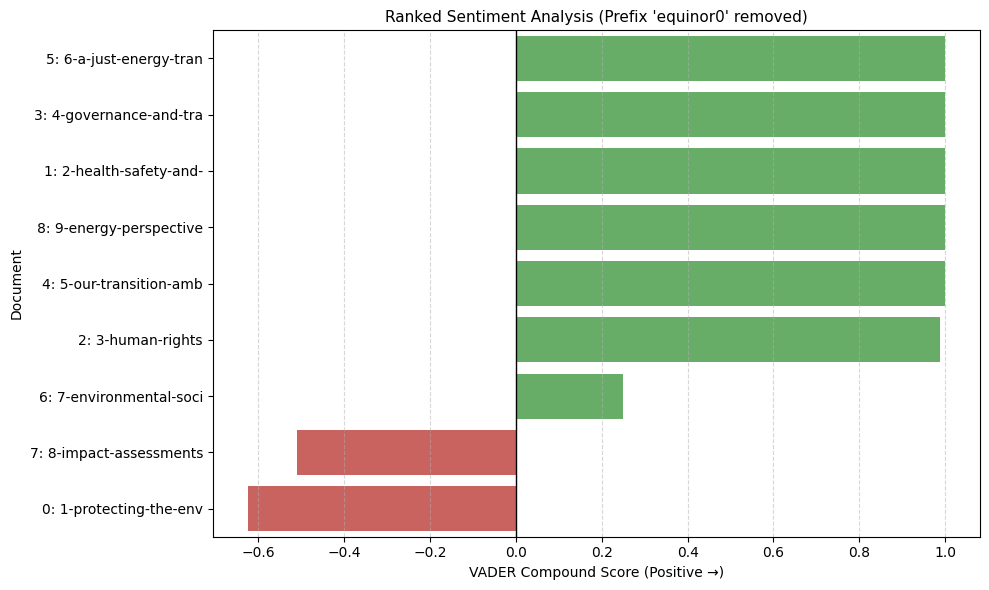

Done! Prefix 'equinor0' was stripped and FutureWarning resolved.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import os

# Ensure VADER lexicon is downloaded
nltk.download('vader_lexicon', quiet=True)

# 1. Setup Path and Load Files
DATA_DIR = Path("/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor")
files = sorted(list(DATA_DIR.glob("*.txt")))[:10]

# Identify common prefix
stems = [f.stem for f in files]
common_prefix = os.path.commonprefix(stems)
prefix_len = len(common_prefix)

analyzer = SentimentIntensityAnalyzer()
results = []

# 2. Process Documents
for i, file_path in enumerate(files):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()

    scores = analyzer.polarity_scores(text)

    unique_part = file_path.stem[prefix_len:]
    clean_label = f"{i}: {unique_part[:20]}"

    results.append({
        "label": clean_label,
        "filename": file_path.name,
        "sentiment_score": scores['compound']
    })

# 3. Create DataFrame and Sort
df = pd.DataFrame(results)
df_sorted = df.sort_values("sentiment_score", ascending=False)

# 4. Save as TSV
df_sorted.to_csv("sentiment_results.tsv", sep='\t', index=False)

# 5. Visualize as Horizontal Bar Chart
plt.figure(figsize=(10, 6))

# Map colors
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in df_sorted["sentiment_score"]]

# --- UPDATED: Fixed FutureWarning by adding hue and legend=False ---
sns.barplot(
    data=df_sorted,
    x="sentiment_score",
    y="label",
    palette=colors,
    hue="label",
    legend=False
)

plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.title(f"Ranked Sentiment Analysis (Prefix '{common_prefix}' removed)", fontsize=11)
plt.xlabel("VADER Compound Score (Positive →)")
plt.ylabel("Document")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 6. Save Figure
plt.tight_layout()
plt.savefig("sentiment_chart.png", dpi=300)
plt.show()

print(f"Done! Prefix '{common_prefix}' was stripped and FutureWarning resolved.")

## TextBlob Sentiment Analysis

This script utilizes the TextBlob library to assess the sentiment and subjectivity of a document collection. It is designed to clean up redundant file naming conventions and provide a ranked visual overview of document "tone."

### 1. File Pre-processing & Prefix Stripping
The script targets the first 10 `.txt` files in a specified Google Drive directory. To ensure the final chart is readable, it automatically detects the **common prefix** (text shared at the start of all filenames) and removes it. This isolates the unique identifiers of each document, which are then truncated to 20 characters for clean labeling.

### 2. Lexicon-Based Sentiment Scoring
Using the **TextBlob** library, the code processes the full text of each file to extract two key metrics:
* **Polarity:** A score from **-1.0 (negative)** to **1.0 (positive)** based on a pre-defined dictionary of words.
* **Subjectivity:** A score from **0.0 (objective/factual)** to **1.0 (subjective/opinion-based)**. While not plotted, this is exported to the final data file for deeper analysis.

### 3. Data Management & Ranking
Results are collected into a Pandas DataFrame and **sorted by polarity in descending order**. This ensures the most "positive" documents appear at the top of the dataset. The complete data—including filenames, truncated labels, sentiment scores, and subjectivity—is saved as a Tab-Separated Values (`.tsv`) file.

### 4. Visualization & Error Handling
The script generates a horizontal bar chart with the following features:
* **Dynamic Colors:** Bars are colored green for positive polarity and red for negative.
* **Future-Proofing:** The plotting logic uses the `hue` assignment to comply with the latest Seaborn API requirements, avoiding deprecation warnings.
* **Robustness:** An `error handling` block (try/except) is included to prevent the script from crashing if an individual file has encoding issues or is unreadable.

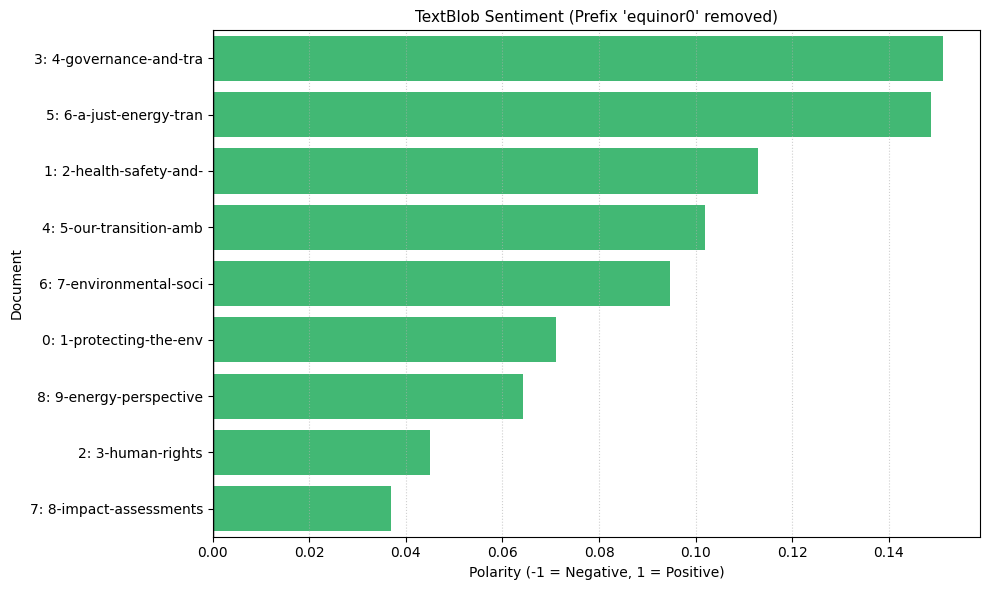

Done! Prefix 'equinor0' was stripped and warnings resolved.
Files generated: textblob_results.tsv and textblob_sentiment.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from textblob import TextBlob
import os

# 1. Setup Path and Load Files
DATA_DIR = Path("/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor")
files = sorted(list(DATA_DIR.glob("*.txt")))[:10]

# Identify common prefix among stems
stems = [f.stem for f in files]
common_prefix = os.path.commonprefix(stems)
prefix_len = len(common_prefix)

results = []

# 2. Process Documents
for i, file_path in enumerate(files):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()

        # Initialize TextBlob
        blob = TextBlob(text)

        # Calculate Polarity (-1 to 1) and Subjectivity (0 to 1)
        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity

        # Strip prefix and take 20 chars
        unique_part = file_path.stem[prefix_len:]
        clean_label = f"{i}: {unique_part[:20]}"

        results.append({
            "label": clean_label,
            "filename": file_path.name,
            "sentiment_score": polarity,
            "subjectivity": subjectivity
        })
    except Exception as e:
        print(f"Error processing {file_path.name}: {e}")

# 3. Create DataFrame and Sort (Highest score at top)
df = pd.DataFrame(results)
df_sorted = df.sort_values("sentiment_score", ascending=False)

# 4. Save as TSV
df_sorted.to_csv("textblob_results.tsv", sep='\t', index=False)

# 5. Visualize as Horizontal Bar Chart
plt.figure(figsize=(10, 6))

# Color mapping: Green for positive, Red for negative
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in df_sorted["sentiment_score"]]

# Updated barplot to resolve FutureWarning
sns.barplot(
    data=df_sorted,
    x="sentiment_score",
    y="label",
    palette=colors,
    hue="label",
    legend=False
)

plt.axvline(0, color='black', linewidth=1)
plt.title(f"TextBlob Sentiment (Prefix '{common_prefix}' removed)", fontsize=11)
plt.xlabel("Polarity (-1 = Negative, 1 = Positive)")
plt.ylabel("Document")
plt.grid(axis='x', linestyle=':', alpha=0.6)

# 6. Save Figure
plt.tight_layout()
plt.savefig("textblob_sentiment.png", dpi=300)
plt.show()

print(f"Done! Prefix '{common_prefix}' was stripped and warnings resolved.")
print("Files generated: textblob_results.tsv and textblob_sentiment.png")

## 2. From Tokens to Vectors: Towards Sentence-Level Sentiment
*(Ghosh & Gunning 2019, Ch. 7)*

The limitations above motivate a shift from dictionary lookup to **vector representations**. In Ch. 7, Ghosh & Gunning explain why text must be converted to numbers for machine learning: *"Machine learning algorithms cannot work directly on raw text. We need to convert text into numbers"* (p. 220).

### How vector representations improve sentiment analysis

When text is encoded as a **dense vector** (e.g. using spaCy's `en_core_web_md` 300-dimensional word embeddings), each word or sentence occupies a *position* in a continuous semantic space. Words with similar meanings cluster nearby. This enables a more powerful approach to sentence-level sentiment:

1. **Sentence vector** — compute `doc.vector` for each sentence (mean of its token vectors in spaCy)
2. **Polarity anchors** — define prototype vectors for *positive* and *negative* sentiment (e.g. from known positive/negative seed words)
3. **Cosine similarity** — score each sentence by how close it is to the positive vs. negative anchor

```python
import spacy
nlp = spacy.load("en_core_web_md")

positive_anchor = nlp("good excellent great benefit success opportunity")
negative_anchor = nlp("risk harm damage failure loss problem")

sentence = nlp("We are committed to reducing our environmental impact.")
pos_sim = sentence.similarity(positive_anchor)
neg_sim = sentence.similarity(negative_anchor)
sentiment = pos_sim - neg_sim   # positive → net positive sentiment
```

Unlike AFINN, this approach:
- Captures **semantic proximity** (e.g. *"transition"* near *"opportunity"* in vector space)
- Works on **whole sentences**, not isolated tokens
- Is sensitive to the **combination** of words, not just individual scores

The next section applies spaCy vectors to the Equinor corpus directly.

## Vector Representation of Text
*(Ghosh & Gunning 2019, Ch. 7)*

*"At the heart of NLP is the simple trick of representing text as numbers. This helps software algorithms to perform the sophisticated computations that are required to understand the meaning of text."* (p. 220)

Ch. 7 introduces a progression of encoding techniques — from simple integer and one-hot encoding through to **word embeddings**: dense, low-dimensional vectors where *"each individual embedding vector contains information about the meaning of a single word"* and where *"word meanings are determined by looking at the word and other words that tend to surround it in the sentences"* (p. 245).

We use **spaCy's `en_core_web_md` model**, which ships 300-dimensional GloVe-based vectors for ~20,000 words. This is an instance of **transfer learning** — *"the application of training from one project to another"* (p. 252): the vectors were trained on a large general-language corpus and we apply them directly to our sustainability texts without any further training.

Two levels of vector are available in spaCy:
- **`token.vector`** — the 300-dim embedding for a single word
- **`doc.vector`** — the mean of all token vectors in the document (a compact document-level representation)

### Accessing word vectors
Word vectors (embeddings) transform text into numerical coordinates in a high-dimensional **semantic space**. Instead of treating words as simple strings, this approach captures **meaning through context**.

* **Spatial Relationships:** Words with similar meanings (e.g., *carbon* and *emissions*) are placed closer together mathematically.
* **The "md" Model:** We use the medium spaCy model because it contains **300-dimensional vectors** for 20,000 unique words, providing the "coordinates" necessary for semantic math.
* **OOV (Out-Of-Vocabulary):** If a word is unknown to the model (like `skod52`), it lacks a coordinate and returns a vector of zeros (`is_oov = True`).



### 2. Coding Level
The script ensures environment readiness and validates data integrity through three main steps:

* **Self-Healing Setup:** Uses a `try/except` block with `spacy.cli.download` to automatically fetch the medium model if it is missing from the system.
* **Tokenization:** Wraps strings in `nlp()` to generate **Token** objects, which serve as the container for the underlying vector data.
* **Validation Attributes:** * `.is_oov`: Detects if a word is missing from the pre-trained dictionary.
    * `.vector.shape`: Confirms the dimensions (300).
    * `.vector.sum()`: A quick sanity check; a sum of `0.0` identifies "invisible" OOV terms.

In [ ]:
import spacy
import numpy as np
from spacy.cli import download

# 1. Download and load the medium model (includes 20k unique vectors)
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading 'en_core_web_md'...")
    download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

# 2. Define words for showcase
word_real = "sustainability"
word_oov = "skod52_equinor_2025_tag"

# 3. Process words
# We wrap them in nlp() to create Doc objects
token_real = nlp(word_real)[0]
token_oov = nlp(word_oov)[0]

# 4. Print Vector Statistics
print(f"--- REAL WORD INSPECTION: '{word_real}' ---")
print(f"Is OOV?       : {token_real.is_oov}")
print(f"Vector Shape : {token_real.vector.shape}")
print(f"First 10 dims: {token_real.vector[:10]}")
print(f"Vector Sum   : {token_real.vector.sum():.4f}\n")

print(f"--- OOV WORD INSPECTION: '{word_oov}' ---")
print(f"Is OOV?       : {token_oov.is_oov}")
print(f"Vector Shape : {token_oov.vector.shape}")
print(f"Vector Sum   : {token_oov.vector.sum():.4f}")
print("\nNote: OOV vectors are 0.0 because 'md' models use a static vocabulary.")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
--- REAL WORD INSPECTION: 'sustainability' ---
Is OOV?       : False
Vector Shape : (300,)
First 10 dims: [-0.69805   0.091233  0.32271  -0.067161 -0.01951   0.16902   0.046288
  0.32337  -0.88247   1.4999  ]
Vector Sum   : 11.6457

--- OOV WORD INSPECTION: 'skod52_equinor_2025_tag' ---
Is OOV?       : True
Vector Shape : (300,)
Vector Sum   : 0.0000

Note: OOV vectors are 0.0 because 'md' models use a static vocabulary.


### Comparing word vectors

Word similarity is measured by **Cosine Similarity**, which calculates the distance between two numerical "coordinates" in semantic space.

* **Directional Alignment:** The model looks at the angle between vectors. A score of **1.0** indicates identical usage contexts, while **0.0** indicates no shared context.
* **Contextual Co-occurrence:** "Gas" and "Oil" score high because they are frequently surrounded by the same terms (e.g., *price, energy, supply*) in training data.
* **Semantic Noise:** Dissimilar words like "Gas" and "Penguin" share almost no linguistic environment, resulting in a low score.

### 2. Coding Level
The implementation is a direct comparison of two spaCy `Token` or `Doc` objects:

* **The `.similarity()` Method:** This is the primary interface for the calculation. It automatically handles the dot product and magnitude division of the two 300-dimensional arrays.
* **Precision Formatting:** Using f-strings like `{score:.4f}` is standard practice to round the long float returned by the similarity engine, making the output human-readable.
* **Object Consistency:** While we use single words here, the `.similarity()` method works across all spaCy containers, allowing you to compare a `Token` to a `Doc` or a `Span` to a `Span`.

In [ ]:
import spacy
from spacy.cli import download

# 1. Environment Setup
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

# 2. Define Word Pairs
# Pair A: Semantically Similar
word1, word2 = nlp("gas"), nlp("oil")

# Pair B: Semantically Dissimilar
word3, word4 = nlp("gas"), nlp("penguin")

# 3. Compute and Print Results
print(f"--- Semantic Similarity Results ---")

# Similar Pair
sim_score = word1.similarity(word2)
print(f"SIMILAR:    '{word1.text}' & '{word2.text}' -> Score: {sim_score:.4f}")

# Dissimilar Pair
dissim_score = word3.similarity(word4)
print(f"DISSIMILAR: '{word3.text}' & '{word4.text}' -> Score: {dissim_score:.4f}")

--- Semantic Similarity Results ---
SIMILAR:    'gas' & 'oil' -> Score: 0.3785
DISSIMILAR: 'gas' & 'penguin' -> Score: 0.0713


### Visualizing word vectors
Because humans cannot visualize 300-dimensional space, we use **Principal Component Analysis (PCA)** to "flatten" the data into a 2D map.

* **Dimensionality Reduction:** PCA identifies the axes of greatest variation, preserving the relative distances between words.
* **Semantic Clustering:** Even after reduction, words from the same domain (e.g., *Sustainability*) cluster together, while distinct domains (e.g., *Sports*) form separate "islands" in the semantic space.
* **Vector Math:** This visualization proves that the model "understands" category differences based solely on word usage patterns it learned during training.



### 2. Coding Level
The implementation uses a streamlined data science pipeline to transform raw vectors into a high-quality visualization:

* **Vector Aggregation:** Converts a list of spaCy vectors into a **NumPy matrix**, creating a structured dataset for the PCA algorithm.
* **Scikit-Learn Integration:** Uses `PCA(n_components=2)` to calculate the X and Y coordinates that represent the "best" 2D summary of the original 300 dimensions.
* **Seaborn Visualization:** * **Hue Mapping:** Automatically colors points based on the 'category' label.
    * **Annotations:** Uses `plt.text` to overlay the specific word onto its coordinate, making the clusters immediately interpretable.
* **Data Export:** Saves the coordinates to a `.tsv` file, allowing the results to be re-plotted or audited in external tools.

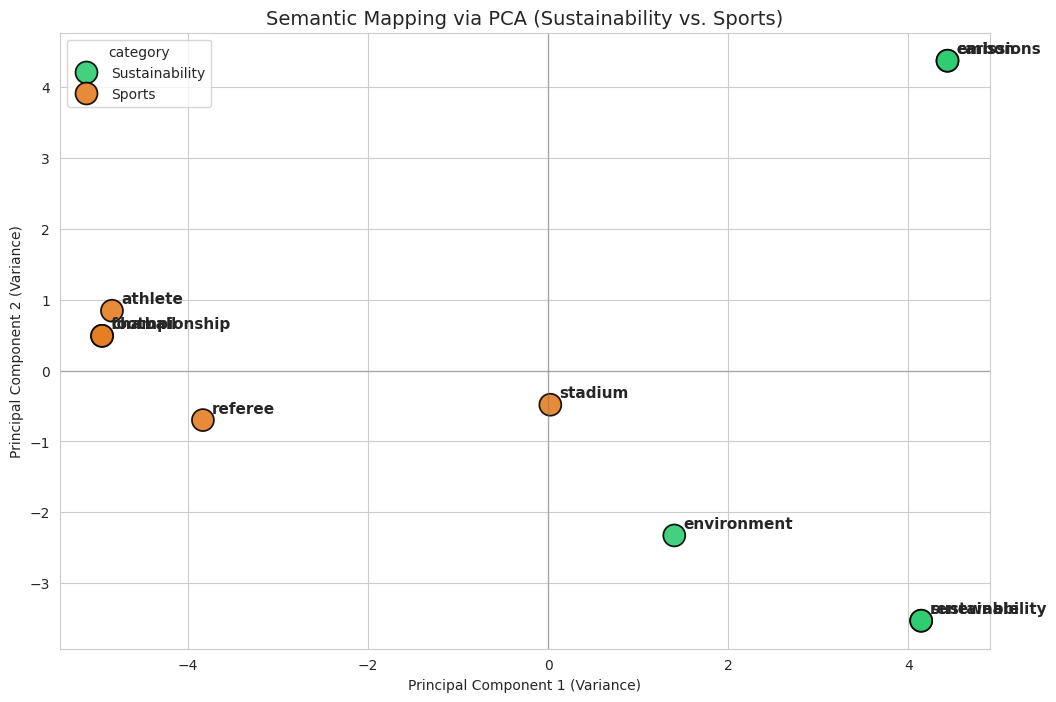

Visualization saved as 'semantic_pca_plot.png'.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Define semantic sets
sust_list = ["sustainability", "emissions", "renewable", "carbon", "environment"]
sport_list = ["football", "athlete", "championship", "stadium", "referee"]
all_words = sust_list + sport_list

# 2. Extract vectors from model
vectors = np.array([nlp(w).vector for w in all_words])

# 3. Perform PCA (Dimensionality Reduction)
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

# 4. Organize Data for plotting
df = pd.DataFrame(coords, columns=['x', 'y'])
df['word'] = all_words
df['category'] = (['Sustainability'] * len(sust_list)) + (['Sports'] * len(sport_list))

# 5. Plotting
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Custom Palette
palette = {"Sustainability": "#2ecc71", "Sports": "#e67e22"}

# Draw Scatter
plot = sns.scatterplot(
    data=df, x='x', y='y', hue='category',
    palette=palette, s=250, edgecolor='black', alpha=0.9
)

# Annotate each point
for i in range(df.shape[0]):
    plt.text(
        df.x[i] + 0.1, df.y[i] + 0.1,
        df.word[i], fontsize=11, fontweight='semibold'
    )

plt.title("Semantic Mapping via PCA (Sustainability vs. Sports)", fontsize=14)
plt.xlabel("Principal Component 1 (Variance)")
plt.ylabel("Principal Component 2 (Variance)")
plt.axhline(0, color='gray', lw=1, alpha=0.5)
plt.axvline(0, color='gray', lw=1, alpha=0.5)

# 6. Save results
plt.savefig("semantic_pca_plot.png", dpi=300)
df.to_csv("vector_coordinates.tsv", sep='\t', index=False)
plt.show()

print("Visualization saved as 'semantic_pca_plot.png'.")

### Document word similarity
This analysis moves from comparing words to comparing **entire themes**. It measures how much a specific document "resembles" a concept in high-dimensional space.

* **Document Centroids:** spaCy creates a single vector for a document by calculating the average of all individual word vectors within it. This "centroid" represents the document's overall semantic fingerprint.
* **Semantic "Presence":** You can find a relationship even without keyword matches. For example, a report discussing "wind turbines" and "solar panels" will have high similarity to the term *renewable*, even if the word *renewable* never appears.
* **Cosine Similarity:** The score (0.0 to 1.0) measures the cosine of the angle between vectors. A smaller angle (closer to 1.0) means the document and the term are conceptually aligned.



### 2. Coding Level
The implementation uses a matrix-based approach to compare document averages against target anchors:

* **Vector Averaging:** By calling `nlp(text)`, spaCy automatically handles the heavy lifting of identifying tokens, retrieving their 300-dim vectors, and averaging them into a single `Doc` vector.
* **The `.similarity()` Method:** This calculates the dot product of normalized vectors. We compare the `Doc` object directly against `Doc` objects created from our target terms.
* **Heatmap Logic:** * **Data Structure:** Results are stored in a Pandas DataFrame where rows are files and columns are terms.
    * **Normalization:** The `YlGnBu` (Yellow-Green-Blue) colormap allows for quick visual identification of "hot spots"—documents where sustainability or sports themes are most dominant.
    * **Annotation:** `annot=True` overlays the raw similarity scores, allowing for precise quantitative auditing alongside the visual trends.

Files generated: term_doc_similarity.png and term_doc_similarity.tsv


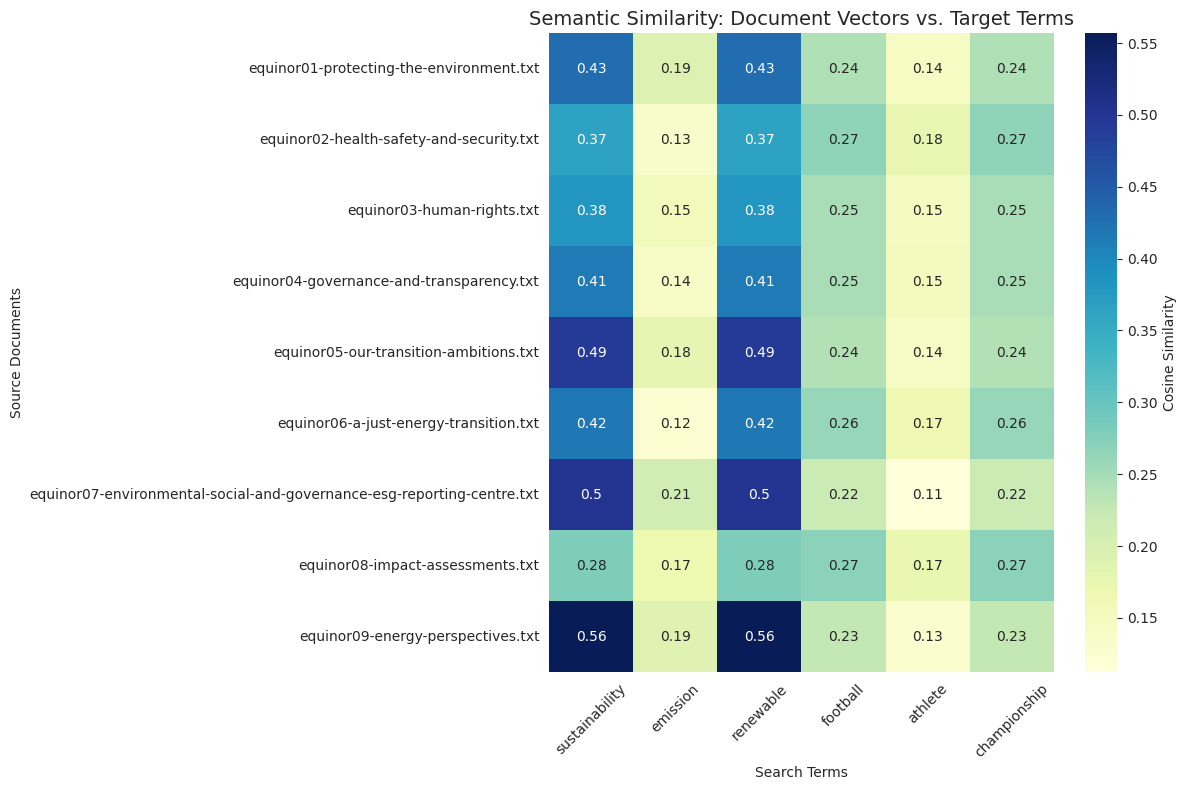

In [ ]:
import spacy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from spacy.cli import download

# 1. Environment Setup
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    download("en_core_web_md")
    nlp = spacy.load("en_core_web_md")

# 2. Configuration
DATA_DIR = Path("/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor")
files = sorted(list(DATA_DIR.glob("*.txt")))[:10]

# Previous terms: 3 Sustainability vs 3 Sports
target_terms = ["sustainability", "emission", "renewable", "football", "athlete", "championship"]
term_docs = [nlp(term) for term in target_terms]

# 3. Process Documents
doc_results = []
for file_path in files:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
            # spaCy automatically averages word vectors to create a doc vector
            doc = nlp(text)

            # Calculate similarity between current doc and each target term
            scores = {term: doc.similarity(t_doc) for term, t_doc in zip(target_terms, term_docs)}
            scores['filename'] = file_path.name
            doc_results.append(scores)
    except Exception as e:
        print(f"Error processing {file_path.name}: {e}")

# 4. Organize Data
df_sim = pd.DataFrame(doc_results).set_index('filename')

# 5. Visualization
plt.figure(figsize=(12, 8))
# We use a heatmap to show the "intensity" of semantic relationship
sns.heatmap(df_sim, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Cosine Similarity'})

plt.title("Semantic Similarity: Document Vectors vs. Target Terms", fontsize=14)
plt.xlabel("Search Terms")
plt.ylabel("Source Documents")
plt.xticks(rotation=45)

# 6. Save Results
plt.tight_layout()
plt.savefig("term_doc_similarity.png", dpi=300)
df_sim.to_csv("term_doc_similarity.tsv", sep='\t')

print("Files generated: term_doc_similarity.png and term_doc_similarity.tsv")